In [20]:
import sys
sys.path.insert(0, '../..')

from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.result import marginal_counts, marginal_distribution

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino

from qiskit.visualization import plot_histogram

import os
import pickle
import numpy as np
import networkx as nx

# Import from network_emulation
from network_emulation import (
    # Static mappings
    NODE_PHYSICAL_QUBITS_513,
    EDGE_PHYSICAL_QUBITS_ES,
    PATH_PHYSICAL_QUBITS_ES,
    TOTAL_QUBITS_ES,
    get_edge_key,
    # Dynamic allocation
    PathQubitAllocation,
    remap_noise_model,
    # Code operations
    apply_encoding_513,
    apply_syndrome_measurement_513,
)

# [[5,1,3]] Code Transport via Entanglement Swapping

This notebook implements quantum state transport using entanglement swapping instead of direct SWAP chains.

## Protocol Overview

For a path A → B → C → D:

1. **Bell Pair Distribution**: Create noisy Bell pairs on each edge
2. **Entanglement Swapping**: At intermediate nodes, perform Bell measurements to extend entanglement
3. **Teleportation**: Bell measurement at source teleports encoded state to sink
4. **Syndrome Measurement**: Extract syndrome at sink (no corrections applied)

# Constants and Configuration

In [21]:
MAX_HOPS = 3
MIN_HOPS = 2
NUM_SHOTS = 4096
OPTIMIZATION_LEVEL = 0


SEED = 1234
SKIP_EXISTING_PATHS = False
NETWORK_GRAPH = '../../networkgraphs/2x3_grid_network_graph.pkl'

# Physical Qubit Mapping

## Layout:
- **Node qubits**: 9 per node (5 data + 4 ancilla)
- **Edge qubits**: 10 per edge (5 for left node + 5 for right node) for Bell pairs

In [22]:
# Compact mapping summary will be printed after loading the network graph.
# Mapping strategy:
# - 5 data qubits per node
# - 10 Bell-pair qubits per edge
# - 1 path qubit per edge
# - 4 shared ancilla qubits (used only at sink)


# Noise Model Setup

In [23]:
# Base noise model from FakeFez
fake_backend = FakeFez()


base_noise_model = NoiseModel.from_backend(fake_backend)
FEZ_BASIS_GATES = base_noise_model.basis_gates

# Compute average 2Q error rates for gates in the backend basis
TWOQ_GATES = [g for g in ['ecr', 'cz', 'cx'] if g in FEZ_BASIS_GATES]
AVG_2Q_ERRORS = {}
for gate in TWOQ_GATES:
    errors = []
    if gate in fake_backend.target.operation_names:
        for qargs in fake_backend.target.qargs_for_operation_name(gate):
            props = fake_backend.target[gate][qargs]
            if props and props.error is not None and np.isfinite(props.error) and 0 < props.error < 1:
                errors.append(float(props.error))
    avg = float(np.mean(errors)) if errors else 0.0
    AVG_2Q_ERRORS[gate] = avg if (0 < avg < 1) else 0.0

print(f"Backend: {fake_backend.name} ({fake_backend.num_qubits} qubits)")
print(f"Basis gates: {FEZ_BASIS_GATES}")
print(f"2Q gates: {TWOQ_GATES}")
print("For dynamic allocation, noise model will be remapped per-path")
print("to maintain consistent physical qubit noise characteristics.")


def augment_noise_for_circuit(remapped_noise, transpiled_circuit, avg_twoq_errors, verbose=False):
    """
    Add missing 2Q errors for pairs actually used in the transpiled circuit.
    """
    for gate, avg_err in avg_twoq_errors.items():
        if avg_err is None or (not np.isfinite(avg_err)) or avg_err <= 0 or avg_err >= 1:
            continue
        error_2q = depolarizing_error(avg_err, 2)
        existing = set(remapped_noise._local_quantum_errors.get(gate, {}).keys())
        added = 0
        for inst in transpiled_circuit.data:
            if inst.operation.name != gate:
                continue
            q0 = transpiled_circuit.find_bit(inst.qubits[0]).index
            q1 = transpiled_circuit.find_bit(inst.qubits[1]).index
            if (q0, q1) not in existing:
                remapped_noise.add_quantum_error(error_2q, gate, [q0, q1])
                existing.add((q0, q1))
                added += 1
        if verbose and added:
            print(f"Added {added} missing {gate} errors for this circuit")
    return remapped_noise


Backend: fake_fez (156 qubits)
Basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
2Q gates: ['cz']
For dynamic allocation, noise model will be remapped per-path
to maintain consistent physical qubit noise characteristics.


# Load Network Graph

Compact Entanglement Swapping Allocation:
  Nodes: 6 × 5 = 30 data qubits
  Edges: 7 × 10 = 70 Bell-pair qubits
  Paths: 7 × 1 = 7 path qubits
  Shared ancilla pool: 4 qubits
  Total: 111 qubits


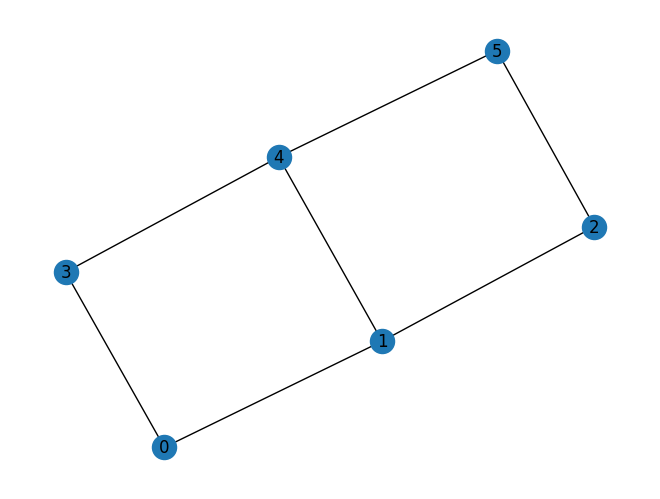

In [24]:
with open(NETWORK_GRAPH, 'rb') as f:
    network_graph = pickle.load(f)

nx.draw(network_graph, with_labels=True)
# -----------------------------------------------------------------------------
# COMPACT PHYSICAL MAPPING (5 data qubits/node + shared ancilla pool)
# -----------------------------------------------------------------------------
# Build a compact mapping that fits within the backend qubit count.
# Total = 5*|V| + 11*|E| + 4

_nodes = sorted(network_graph.nodes())
_edges = sorted({get_edge_key(u, v) for u, v in network_graph.edges()})

idx = 0
NODE_DATA_QUBITS_ES_LITE = {}
for n in _nodes:
    NODE_DATA_QUBITS_ES_LITE[n] = list(range(idx, idx + 5))
    idx += 5

EDGE_PHYSICAL_QUBITS_ES_LITE = {}
for e in _edges:
    EDGE_PHYSICAL_QUBITS_ES_LITE[e] = list(range(idx, idx + 10))
    idx += 10

PATH_PHYSICAL_QUBITS_ES_LITE = {}
for e in _edges:
    PATH_PHYSICAL_QUBITS_ES_LITE[e] = idx
    idx += 1

ANCILLA_PHYSICAL_QUBITS_ES_LITE = list(range(idx, idx + 4))
idx += 4

TOTAL_QUBITS_ES_LITE = idx

if TOTAL_QUBITS_ES_LITE > fake_backend.num_qubits:
    raise ValueError(
        f"Compact mapping requires {TOTAL_QUBITS_ES_LITE} qubits, "
        f"but backend provides {fake_backend.num_qubits}."
    )

print("Compact Entanglement Swapping Allocation:")
print(f"  Nodes: {len(_nodes)} × 5 = {len(_nodes) * 5} data qubits")
print(f"  Edges: {len(_edges)} × 10 = {len(_edges) * 10} Bell-pair qubits")
print(f"  Paths: {len(_edges)} × 1 = {len(_edges)} path qubits")
print(f"  Shared ancilla pool: 4 qubits")
print(f"  Total: {TOTAL_QUBITS_ES_LITE} qubits")


In [25]:
from itertools import combinations

ALL_HOP_PATHS = []
for pairs in combinations(network_graph.nodes, 2):
    multi_hop_paths = nx.all_simple_paths(network_graph, source=pairs[0], target=pairs[1], cutoff=MAX_HOPS)
    ALL_HOP_PATHS.extend([x for x in multi_hop_paths if len(x) > MIN_HOPS])

print(f"Total paths to process: {len(ALL_HOP_PATHS)}")
print(f"Sample paths: {ALL_HOP_PATHS[:5]}")

Total paths to process: 24
Sample paths: [[0, 3, 4, 1], [0, 1, 2], [0, 1, 4, 3], [0, 1, 4], [0, 3, 4]]


# [[5,1,3]] Code Helpers

Stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ

In [26]:
# [[5,1,3]] code functions imported from network_emulation:
# - apply_encoding_513(qc, qubits)
# - apply_syndrome_measurement_513(qc, data_qubits, ancilla_qubits, classical_bits)

print("[[5,1,3]] Code:")
print("  Stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ")
print("  5 data qubits, 4 ancilla qubits")
print("  Corrects any single-qubit error")

[[5,1,3]] Code:
  Stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ
  5 data qubits, 4 ancilla qubits
  Corrects any single-qubit error


# Entanglement Swapping Primitives

In [27]:
# =============================================================================
# ENTANGLEMENT PRIMITIVES
# =============================================================================

def create_and_distribute_bell_pair(qc, local_qubit, remote_qubit, path_qubit):
    """
    Create a Bell pair locally and distribute one half via physical SWAP.
    
    Protocol:
        1. Create Bell pair: |Φ+⟩ = (|00⟩ + |11⟩)/√2 between local_qubit and path_qubit
        2. SWAP path_qubit to remote_qubit (this is the noisy channel)
    
    Result: local_qubit and remote_qubit share a Bell pair.
    
    Args:
        qc: QuantumCircuit
        local_qubit: Qubit index that stays at the sender
        remote_qubit: Qubit index at the receiver (destination)
        path_qubit: Channel qubit used for physical transport
    """
    # Create Bell pair between local qubit and path qubit
    qc.h(local_qubit)
    qc.cx(local_qubit, path_qubit)
    
    # SWAP path qubit to remote qubit (noisy channel operation)
    qc.swap(path_qubit, remote_qubit)


def distribute_bell_pairs_sequential(qc, sender_qubits, receiver_qubits, path_qubit):
    """
    Distribute 5 Bell pairs from sender to receiver via physical SWAPs.
    
    Each of the 5 code qubits gets its own Bell pair:
        - sender_qubits[i] holds one half
        - receiver_qubits[i] holds the other half (after SWAP through channel)
    
    Args:
        qc: QuantumCircuit
        sender_qubits: List of 5 qubit indices at sender node
        receiver_qubits: List of 5 qubit indices at receiver node
        path_qubit: Single path qubit index (channel) - reused for all 5 pairs
    """
    for i in range(5):
        create_and_distribute_bell_pair(qc, sender_qubits[i], receiver_qubits[i], path_qubit)


def apply_bell_measurement(qc, qubits_a, qubits_b, classical_bits):
    """
    Perform Bell measurements on pairs of qubits.
    
    Bell measurement: CNOT(a→b), H(a), then measure both.
    
    Measurement outcomes encode required Pauli corrections:
        classical_bits[i]   (from qubit_a after H) → Z correction needed if 1
        classical_bits[i+5] (from qubit_b)         → X correction needed if 1
    
    Args:
        qc: QuantumCircuit
        qubits_a: List of 5 qubit indices (control)
        qubits_b: List of 5 qubit indices (target)
        classical_bits: List/register of 10 classical bits
    """
    for i, (qa, qb) in enumerate(zip(qubits_a, qubits_b)):
        qc.cx(qa, qb)
        qc.h(qa)
        qc.measure(qa, classical_bits[i])       # Z correction bit
        qc.measure(qb, classical_bits[i + 5])   # X correction bit


def apply_pauli_corrections(qc, target_qubits, classical_register):
    """
    Apply Pauli corrections based on Bell measurement outcomes.
    
    For teleportation/swapping to work correctly:
        - If classical_bits[i] = 1 → apply Z to target[i]
        - If classical_bits[i+5] = 1 → apply X to target[i]
    
    Multiple corrections from different measurements can be applied
    independently - they XOR correctly (Z² = X² = I).
    
    Args:
        qc: QuantumCircuit
        target_qubits: List of 5 qubit indices to correct
        classical_register: ClassicalRegister with 10 bits from Bell measurement
    """
    for i in range(5):
        # Z correction based on first measurement (bits 0-4)
        with qc.if_test((classical_register[i], 1)):
            qc.z(target_qubits[i])
        
        # X correction based on second measurement (bits 5-9)
        with qc.if_test((classical_register[i + 5], 1)):
            qc.x(target_qubits[i])

# Main Circuit Builder: Entanglement Swapping Protocol

In [28]:
# =============================================================================
# CIRCUIT BUILDERS
# =============================================================================

# Compact dynamic allocation using the lite mapping
class PathQubitAllocationCompactES:
    def __init__(self, path):
        self.path = path
        self.source = path[0]
        self.sink = path[-1]
        self.edges = [(path[i], path[i+1]) for i in range(len(path)-1)]

        idx = 0
        self.physical_map = {}

        # Source data qubits
        self.source_data = []
        for i in range(5):
            self.source_data.append(idx)
            self.physical_map[idx] = NODE_DATA_QUBITS_ES_LITE[self.source][i]
            idx += 1

        # Edge qubits + path qubits
        self.edge_qubits = {}
        self.path_qubit = {}
        for edge in self.edges:
            edge_key = get_edge_key(edge[0], edge[1])
            orig_edge = EDGE_PHYSICAL_QUBITS_ES_LITE[edge_key]
            orig_path = PATH_PHYSICAL_QUBITS_ES_LITE[edge_key]

            self.edge_qubits[edge_key] = []
            for i in range(10):
                self.edge_qubits[edge_key].append(idx)
                self.physical_map[idx] = orig_edge[i]
                idx += 1

            self.path_qubit[edge_key] = idx
            self.physical_map[idx] = orig_path
            idx += 1

        # Shared ancilla pool (used at sink)
        self.sink_ancilla = []
        for i in range(4):
            self.sink_ancilla.append(idx)
            self.physical_map[idx] = ANCILLA_PHYSICAL_QUBITS_ES_LITE[i]
            idx += 1

        self.total_qubits = idx

    def get_node_edge_qubits(self, node, neighbor):
        edge_key = get_edge_key(node, neighbor)
        qubits = self.edge_qubits[edge_key]
        return qubits[0:5] if node < neighbor else qubits[5:10]

    def get_path_qubit(self, node_a, node_b):
        edge_key = get_edge_key(node_a, node_b)
        return self.path_qubit[edge_key]

    def summary(self):
        lines = [
            f"PathQubitAllocationCompactES for {self.path}",
            f"  Total qubits: {self.total_qubits}",
            f"  Source data: {self.source_data}",
            f"  Sink ancilla: {self.sink_ancilla}",
        ]
        return "\n".join(lines)


def build_entanglement_swapping_circuit_dynamic(path, initial_state='0'):
    """
    Build circuit for [[5,1,3]] code transport via entanglement swapping.
    
    Uses DYNAMIC qubit allocation for faster simulation.
    
    Protocol for path A → B → C → D:
    
    1. ENCODE: Prepare and encode the logical qubit at source (A)
    
    2. SEQUENTIAL BELL PAIR DISTRIBUTION:
       - A creates 5 Bell pairs, SWAPs one half to B (via noisy channel)
       - B creates 5 Bell pairs, SWAPs one half to C (via noisy channel)
       - C creates 5 Bell pairs, SWAPs one half to D (via noisy channel)
       
       After this step:
       - A holds: encoded state + 5 qubits entangled with B
       - B holds: 5 qubits from A + 5 qubits entangled with C
       - C holds: 5 qubits from B + 5 qubits entangled with D
       - D holds: 5 qubits from C
    
    3. ENTANGLEMENT SWAPPING (at intermediate nodes):
       - At B: Bell measurement on (A's qubits at B) and (B's qubits going to C)
         → Extends entanglement: A ↔ C
       - At C: Bell measurement on (qubits from B, now entangled with A) and (C's qubits going to D)
         → Extends entanglement: A ↔ D
    
    4. TELEPORTATION:
       - At A: Bell measurement on (encoded 5 qubits) and (A's entanglement qubits)
       → Teleports encoded state to D's qubits
    
    5. PAULI CORRECTIONS at sink:
       - Apply corrections based on ALL Bell measurement outcomes
    
    6. SYNDROME MEASUREMENT at sink
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2, 3]
        initial_state: '0' or '1'
    
    Returns:
        tuple: (QuantumCircuit, PathQubitAllocation)
    """
    alloc = PathQubitAllocationCompactES(path)
    
    source = path[0]
    sink = path[-1]
    intermediate_nodes = path[1:-1]
    edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    
    # Create circuit with minimal qubits
    qc = QuantumCircuit(alloc.total_qubits)
    
    # Classical registers for Bell measurements
    swap_registers = {}
    for node in intermediate_nodes:
        reg = ClassicalRegister(10, name=f'c_swap_{node}')
        qc.add_register(reg)
        swap_registers[node] = reg
    
    teleport_register = ClassicalRegister(10, name=f'c_teleport_{source}')
    qc.add_register(teleport_register)
    
    syndrome_register = ClassicalRegister(4, name=f'c_syndrome_{sink}')
    qc.add_register(syndrome_register)
    
    # =========================================================================
    # STEP 1: Encode logical qubit at source
    # =========================================================================
    if initial_state == '1':
        qc.x(alloc.source_data[4])
    
    apply_encoding_513(qc, alloc.source_data)
    qc.barrier(label='Encode')
    
    # =========================================================================
    # STEP 2: Sequential Bell pair distribution (with physical SWAPs)
    # =========================================================================
    # For each edge, the "sender" creates Bell pairs and SWAPs one half to "receiver"
    # The SWAP through the path qubit introduces channel noise
    
    for edge in edges:
        sender = edge[0]
        receiver = edge[1]
        edge_key = get_edge_key(sender, receiver)
        
        # Determine which half of edge_qubits belongs to sender vs receiver
        # edge_qubits[0:5] = "left" node (smaller ID), edge_qubits[5:10] = "right" node
        if sender < receiver:
            sender_qubits = alloc.edge_qubits[edge_key][0:5]   # Sender's halves (stay local)
            receiver_qubits = alloc.edge_qubits[edge_key][5:10]  # Receiver's halves (after SWAP)
        else:
            sender_qubits = alloc.edge_qubits[edge_key][5:10]
            receiver_qubits = alloc.edge_qubits[edge_key][0:5]
        
        path_qubit = alloc.path_qubit[edge_key]
        
        # Create Bell pairs at sender, SWAP one half to receiver via channel
        distribute_bell_pairs_sequential(qc, sender_qubits, receiver_qubits, path_qubit)
        qc.barrier(label=f'Bell {sender}→{receiver}')
    
    # =========================================================================
    # STEP 3: Entanglement swapping at intermediate nodes
    # =========================================================================
    # At each intermediate node, we have:
    #   - "incoming" qubits: received from previous node (entangled with source-side)
    #   - "outgoing" qubits: local halves that are entangled with next node
    # Bell measurement on these extends entanglement across the node.
    
    for i, node in enumerate(intermediate_nodes):
        prev_node = path[i]      # Node before this one
        next_node = path[i + 2]  # Node after this one
        
        # Incoming: qubits this node received from prev_node
        # These are the "receiver" qubits from the prev_node → node edge
        incoming_qubits = alloc.get_node_edge_qubits(node, prev_node)
        
        # Outgoing: this node's local qubits that are entangled with next_node
        # These are the "sender" qubits from the node → next_node edge
        outgoing_qubits = alloc.get_node_edge_qubits(node, next_node)
        
        apply_bell_measurement(qc, incoming_qubits, outgoing_qubits, swap_registers[node])
    
    if intermediate_nodes:
        qc.barrier(label='Swap')
    
    # =========================================================================
    # STEP 4: Teleportation from source
    # =========================================================================
    # Bell measurement between encoded qubits and source's entanglement qubits
    # This teleports the encoded state to the sink
    
    first_neighbor = path[1]
    source_link_qubits = alloc.get_node_edge_qubits(source, first_neighbor)
    
    apply_bell_measurement(qc, alloc.source_data, source_link_qubits, teleport_register)
    qc.barrier(label='Teleport')
    
    # =========================================================================
    # STEP 5: Apply Pauli corrections at sink
    # =========================================================================
    # All Bell measurement outcomes require corrections on the sink qubits
    
    last_neighbor = path[-2]
    sink_data_qubits = alloc.get_node_edge_qubits(sink, last_neighbor)
    
    # Apply corrections from all intermediate swaps
    for node in intermediate_nodes:
        apply_pauli_corrections(qc, sink_data_qubits, swap_registers[node])
    
    # Apply corrections from teleportation
    apply_pauli_corrections(qc, sink_data_qubits, teleport_register)
    
    qc.barrier(label='Corrections')
    
    # =========================================================================
    # STEP 6: Syndrome measurement at sink
    # =========================================================================
    apply_syndrome_measurement_513(qc, sink_data_qubits, alloc.sink_ancilla, syndrome_register)
    
    return qc, alloc


def build_entanglement_swapping_circuit_static(path, initial_state='0'):
    """
    Build circuit using STATIC qubit allocation (compact mapping).
    
    Original implementation - uses all qubits regardless of path.
    Kept for comparison and validation.
    
    Args:
        path: List of node IDs
        initial_state: '0' or '1'
    
    Returns:
        QuantumCircuit
    """
    source = path[0]
    sink = path[-1]
    intermediate_nodes = path[1:-1]
    edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    
    qc = QuantumCircuit(TOTAL_QUBITS_ES_LITE)
    
    # Classical registers
    swap_registers = {}
    for node in intermediate_nodes:
        reg = ClassicalRegister(10, name=f'c_swap_{node}')
        qc.add_register(reg)
        swap_registers[node] = reg
    
    teleport_register = ClassicalRegister(10, name=f'c_teleport_{source}')
    qc.add_register(teleport_register)
    
    syndrome_register = ClassicalRegister(4, name=f'c_syndrome_{sink}')
    qc.add_register(syndrome_register)
    
    source_data = NODE_DATA_QUBITS_ES_LITE[source]
    sink_ancilla = ANCILLA_PHYSICAL_QUBITS_ES_LITE
    
    # Helper to get edge qubits for a node
    def get_static_node_edge_qubits(node, neighbor):
        edge_key = get_edge_key(node, neighbor)
        eq = EDGE_PHYSICAL_QUBITS_ES_LITE[edge_key]
        return eq[0:5] if node < neighbor else eq[5:10]
    
    # =========================================================================
    # STEP 1: Encode at source
    # =========================================================================
    if initial_state == '1':
        qc.x(source_data[4])
    apply_encoding_513(qc, source_data)
    qc.barrier(label='Encode')
    
    # =========================================================================
    # STEP 2: Sequential Bell pair distribution
    # =========================================================================
    for edge in edges:
        sender = edge[0]
        receiver = edge[1]
        edge_key = get_edge_key(sender, receiver)
        path_qubit = PATH_PHYSICAL_QUBITS_ES_LITE[edge_key]
        
        if sender < receiver:
            sender_qubits = EDGE_PHYSICAL_QUBITS_ES_LITE[edge_key][0:5]
            receiver_qubits = EDGE_PHYSICAL_QUBITS_ES_LITE[edge_key][5:10]
        else:
            sender_qubits = EDGE_PHYSICAL_QUBITS_ES_LITE[edge_key][5:10]
            receiver_qubits = EDGE_PHYSICAL_QUBITS_ES_LITE[edge_key][0:5]
        
        distribute_bell_pairs_sequential(qc, sender_qubits, receiver_qubits, path_qubit)
        qc.barrier(label=f'Bell {sender}→{receiver}')
    
    # =========================================================================
    # STEP 3: Entanglement swapping at intermediate nodes
    # =========================================================================
    for i, node in enumerate(intermediate_nodes):
        prev_node = path[i]
        next_node = path[i + 2]
        incoming = get_static_node_edge_qubits(node, prev_node)
        outgoing = get_static_node_edge_qubits(node, next_node)
        apply_bell_measurement(qc, incoming, outgoing, swap_registers[node])
    
    if intermediate_nodes:
        qc.barrier(label='Swap')
    
    # =========================================================================
    # STEP 4: Teleportation from source
    # =========================================================================
    source_link = get_static_node_edge_qubits(source, path[1])
    apply_bell_measurement(qc, source_data, source_link, teleport_register)
    qc.barrier(label='Teleport')
    
    # =========================================================================
    # STEP 5: Apply Pauli corrections at sink
    # =========================================================================
    sink_data = get_static_node_edge_qubits(sink, path[-2])
    
    for node in intermediate_nodes:
        apply_pauli_corrections(qc, sink_data, swap_registers[node])
    apply_pauli_corrections(qc, sink_data, teleport_register)
    qc.barrier(label='Corrections')
    
    # =========================================================================
    # STEP 6: Syndrome measurement
    # =========================================================================
    apply_syndrome_measurement_513(qc, sink_data, sink_ancilla, syndrome_register)
    
    return qc
    
    return qc

# Test Circuit Construction

In [29]:
# Test dynamic allocation
test_path = [0, 1, 2]

# Build with dynamic allocation
test_circuit, test_alloc = build_entanglement_swapping_circuit_dynamic(test_path, initial_state='1')

print(f"Path: {test_path}")
print(f"Dynamic qubits: {test_circuit.num_qubits} (vs 175 static)")
print(f"Classical bits: {test_circuit.num_clbits}")
print(f"Gate counts: {test_circuit.count_ops()}")
print()
print(test_alloc.summary())

Path: [0, 1, 2]
Dynamic qubits: 31 (vs 175 static)
Classical bits: 24
Gate counts: OrderedDict({'h': 32, 'cx': 32, 'measure': 24, 'if_else': 20, 'cz': 14, 'swap': 10, 'barrier': 6, 'reset': 4, 'z': 2, 'x': 1})

PathQubitAllocationCompactES for [0, 1, 2]
  Total qubits: 31
  Source data: [0, 1, 2, 3, 4]
  Sink ancilla: [27, 28, 29, 30]


Pre-transpiled circuit (SWAPs visible):


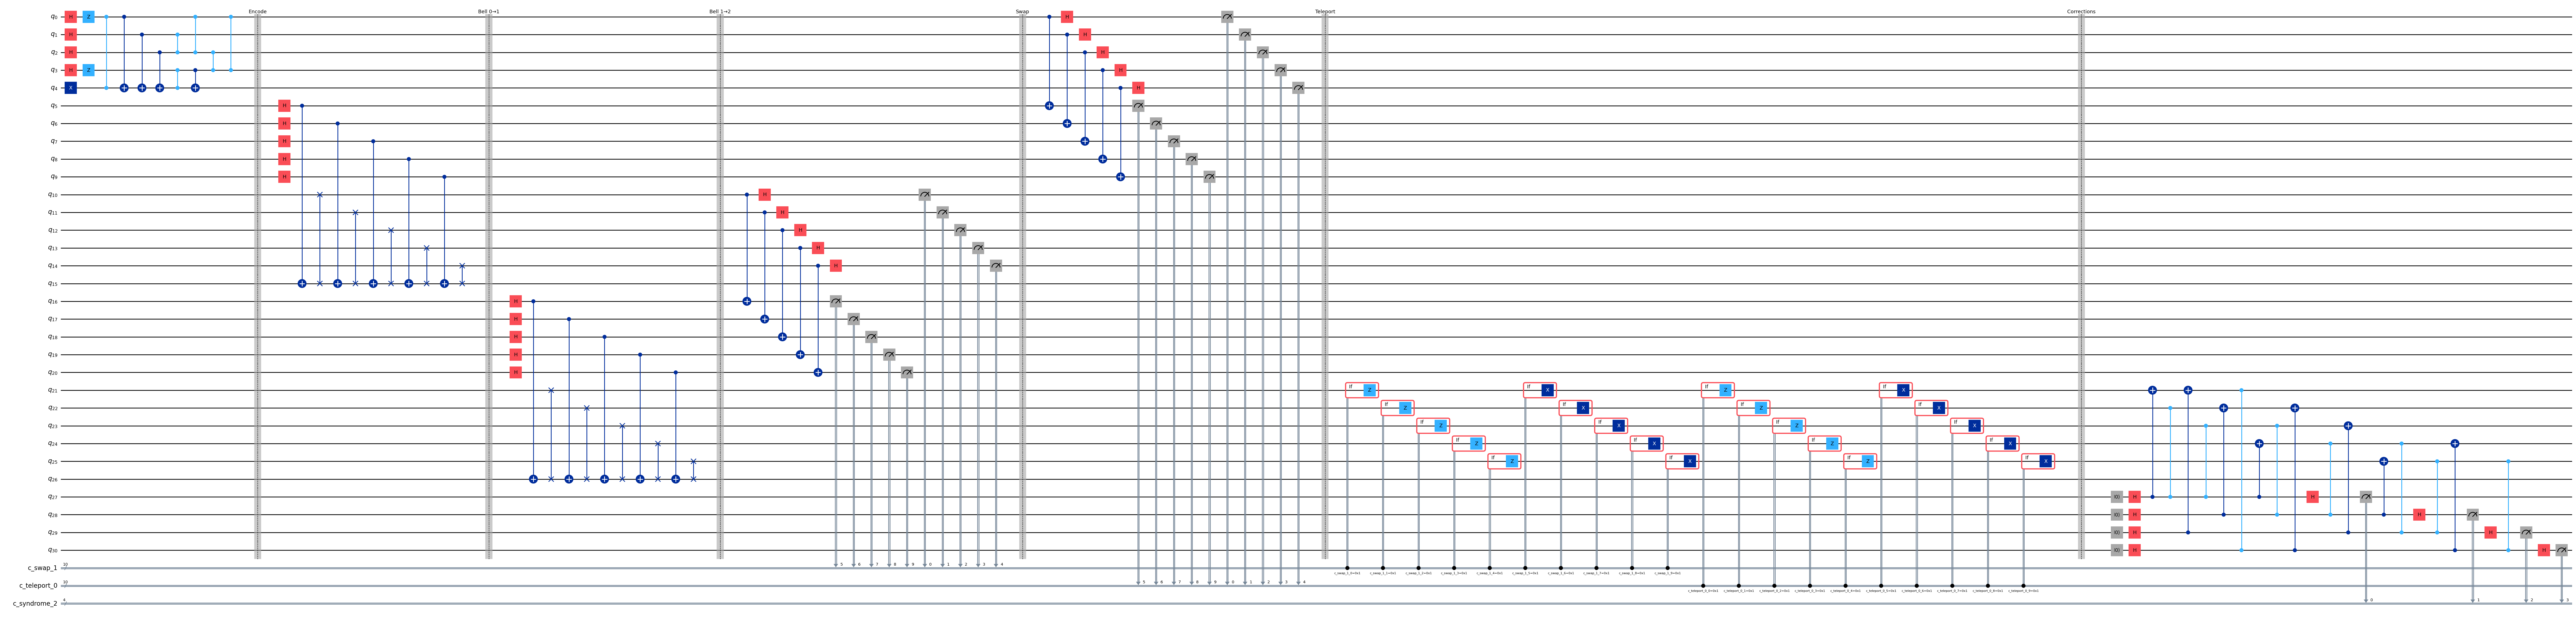

In [30]:
# Draw the circuit BEFORE transpilation to see SWAP gates explicitly
print("Pre-transpiled circuit (SWAPs visible):")
test_circuit.draw('mpl', fold=-1, idle_wires=False)

# Noiseless Simulation Test

In [31]:
# Noiseless simulation (fast - no noise remapping needed)
simulator = AerSimulator(noise_model=None, method='matrix_product_state', seed_simulator=SEED)
transpiled = transpile(test_circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)

print(f"Transpiled gate counts: {transpiled.count_ops()}")

result = simulator.run(transpiled, shots=NUM_SHOTS, seed_simulator=SEED).result()

# Get syndrome counts
syndrome_reg = test_circuit.cregs[-1]
syndrome_indices = [test_circuit.find_bit(bit).index for bit in syndrome_reg]
syndrome_counts = marginal_distribution(result.get_counts(), indices=syndrome_indices)

print(f"Syndrome counts (noiseless): {dict(sorted(syndrome_counts.items()))}")

Transpiled gate counts: OrderedDict({'rz': 194, 'sx': 156, 'cz': 76, 'measure': 24, 'if_else': 20, 'barrier': 6, 'reset': 4, 'x': 1})
Syndrome counts (noiseless): {'0000': 4096}


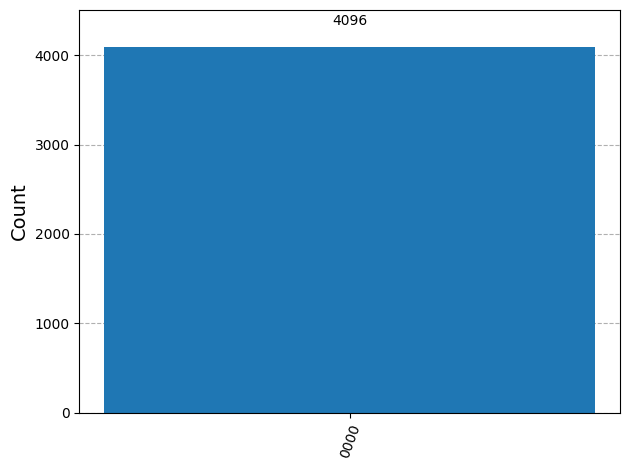

: 

In [ ]:
plot_histogram(syndrome_counts)

# Noisy Simulation Test

In [ ]:
# Noisy simulation with REMAPPED noise model
# This ensures dynamic qubit i gets noise from its corresponding physical qubit

import time

# Remap noise model for this path's allocation
print("Remapping noise model for dynamic allocation...")
start = time.time()
remapped_noise = remap_noise_model(base_noise_model, test_alloc.physical_map)
remapped_noise = augment_noise_for_circuit(remapped_noise, transpiled, AVG_2Q_ERRORS, verbose=True)
print(f"Noise remapping took {time.time() - start:.2f}s")

# Run simulation
noisy_simulator = AerSimulator(noise_model=remapped_noise, method='matrix_product_state', seed_simulator=SEED)

print(f"\nRunning noisy simulation ({test_circuit.num_qubits} qubits)...")
start = time.time()
noisy_result = noisy_simulator.run(transpiled, shots=NUM_SHOTS, seed_simulator=SEED).result()
print(f"Simulation took {time.time() - start:.2f}s")

noisy_syndrome_counts = marginal_distribution(noisy_result.get_counts(), indices=syndrome_indices)
print(f"\nNoisy syndrome counts: {dict(sorted(noisy_syndrome_counts.items()))}")

Simulation failed and returned the following error message:
ERROR:  [Experiment 0] QuantumError: Kraus is empty.


Remapping noise model for dynamic allocation...
Added 51 missing cz errors for this circuit
Noise remapping took 0.03s

Running noisy simulation (31 qubits)...
Simulation took 0.10s


QiskitError: 'ERROR:  [Experiment 0] QuantumError: Kraus is empty. ,  ERROR: QuantumError: Kraus is empty.'

In [ ]:
plot_histogram(noisy_syndrome_counts)

# Data Generation

In [ ]:
class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513_ES'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with additional stats.
        :param code_type: String indicating the code type, e.g., '513_ES' for entanglement swapping.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [ ]:
import time

TIME_AWARE_MEASUREMENTS = []

print("=" * 70)
print("513 ENTANGLEMENT SWAPPING - DYNAMIC ALLOCATION")
print("=" * 70)
print(f"Basis gates: {FEZ_BASIS_GATES}")
print(f"Shots per circuit: {NUM_SHOTS}")
print(f"Total paths: {len(ALL_HOP_PATHS)}")
print("=" * 70)

total_start = time.time()

for path_idx, path in enumerate(ALL_HOP_PATHS):
    path_start = time.time()
    
    # Build circuit with dynamic allocation
    circuit, alloc = build_entanglement_swapping_circuit_dynamic(path, initial_state='0')
    
    # Remap noise model for this path
    remapped_noise = remap_noise_model(base_noise_model, alloc.physical_map)
    
    # Create simulator with remapped noise
    
    # Transpile
    transpiled = transpile(circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)
    remapped_noise = augment_noise_for_circuit(remapped_noise, transpiled, AVG_2Q_ERRORS)
    simulator = AerSimulator(noise_model=remapped_noise, method='matrix_product_state', seed_simulator=SEED)
    
    # Run
    result = simulator.run(transpiled, shots=NUM_SHOTS, seed_simulator=SEED + path_idx).result()
    
    # Extract syndrome
    syndrome_reg = circuit.cregs[-1]
    syndrome_indices = [circuit.find_bit(bit).index for bit in syndrome_reg]
    syndrome_counts = marginal_distribution(result.get_counts(), indices=syndrome_indices)
    
    # Build histogram (ordered by syndrome value)
    histogram = np.array(
        [syndrome_counts.get(f"{i:04b}", 0) for i in range(16)],
        dtype=np.float32
    )
    
    # Store
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    elapsed = time.time() - path_start
    
    measurement = TimeAwareMeasurement(
        path_edges=path_edges,
        histogram=histogram,
        duration=elapsed,
        latency_stats={'total_shots': NUM_SHOTS, 'qubits': alloc.total_qubits},
        code_type='513_ES'
    )
    TIME_AWARE_MEASUREMENTS.append(measurement)
    
    no_error_frac = histogram[0] / histogram.sum()
    print(f"[{path_idx+1}/{len(ALL_HOP_PATHS)}] {path} | "
          f"{alloc.total_qubits}q | {elapsed:.1f}s | no-error: {no_error_frac:.3f}")

total_elapsed = time.time() - total_start
print(f"\n{'=' * 70}")
print(f"Total: {len(TIME_AWARE_MEASUREMENTS)} measurements in {total_elapsed:.1f}s")
print(f"Average: {total_elapsed/len(ALL_HOP_PATHS):.1f}s per path")
print(f"{'=' * 70}")

# Save Data

In [ ]:
DATA_DIR = '../../pickle_files/syndrome_data_513_es/'
os.makedirs(DATA_DIR, exist_ok=True)

with open(os.path.join(DATA_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(TIME_AWARE_MEASUREMENTS, f)

with open(os.path.join(DATA_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)

print(f"Data saved to {DATA_DIR}")

In [ ]:
# =============================================================================
# GROUND TRUTH CIRCUIT (Entanglement Swapping Protocol)
# =============================================================================

def build_ground_truth_circuit_es(path, initial_state='0', measurement_basis='Z'):
    """
    Build a ground truth circuit for single-qubit transport via entanglement swapping.
    
    This circuit teleports a SINGLE (unencoded) qubit from source to sink
    using the same entanglement swapping protocol, and measures in the specified
    basis to determine error rates.
    
    Protocol:
        1. Prepare qubit at source in measurement_basis
        2. Create and distribute Bell pairs along the path (via SWAP through channels)
        3. Entanglement swapping at intermediate nodes (Bell measurements)
        4. Teleportation from source (Bell measurement)
        5. Apply Pauli corrections at sink
        6. Rotate back to Z-basis and measure
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2, 3]
        initial_state: '0' or '1'
        measurement_basis: 'X', 'Y', or 'Z'
    
    Returns:
        tuple: (QuantumCircuit, PathQubitAllocation)
    """
    alloc = PathQubitAllocationCompactES(path)
    
    source = path[0]
    sink = path[-1]
    intermediate_nodes = path[1:-1]
    edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    
    # Create circuit - we only use 1 qubit at source (index 0) instead of 5
    qc = QuantumCircuit(alloc.total_qubits)
    
    # Classical registers for Bell measurements
    swap_registers = {}
    for node in intermediate_nodes:
        # 2 bits per intermediate node (1 qubit pair)
        reg = ClassicalRegister(2, name=f'c_swap_{node}')
        qc.add_register(reg)
        swap_registers[node] = reg
    
    # 2 bits for teleportation (1 qubit pair)
    teleport_register = ClassicalRegister(2, name=f'c_teleport_{source}')
    qc.add_register(teleport_register)
    
    # 1 bit for final measurement
    measure_register = ClassicalRegister(1, name='c_measure')
    qc.add_register(measure_register)
    
    # =========================================================================
    # STEP 1: Prepare initial state at source (single qubit, index 0)
    # =========================================================================
    source_qubit = alloc.source_data[0]  # Use only first qubit
    
    if initial_state == '1':
        qc.x(source_qubit)
    
    # Rotate to measurement basis
    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)
        qc.s(source_qubit)
    
    qc.barrier(label='Init')
    
    # =========================================================================
    # STEP 2: Sequential Bell pair distribution (1 Bell pair per edge)
    # =========================================================================
    for edge in edges:
        sender = edge[0]
        receiver = edge[1]
        edge_key = get_edge_key(sender, receiver)
        
        # Use only first qubit of each edge's allocation
        if sender < receiver:
            sender_qubit = alloc.edge_qubits[edge_key][0]     # Sender's half
            receiver_qubit = alloc.edge_qubits[edge_key][5]   # Receiver's half
        else:
            sender_qubit = alloc.edge_qubits[edge_key][5]
            receiver_qubit = alloc.edge_qubits[edge_key][0]
        
        path_qubit = alloc.path_qubit[edge_key]
        
        # Create Bell pair at sender, SWAP to receiver
        qc.h(sender_qubit)
        qc.cx(sender_qubit, path_qubit)
        qc.swap(path_qubit, receiver_qubit)
    
    qc.barrier(label='Bell Pairs')
    
    # =========================================================================
    # STEP 3: Entanglement swapping at intermediate nodes (single qubit)
    # =========================================================================
    def get_single_node_edge_qubit(node, neighbor):
        """Get the single edge qubit for this node-neighbor pair."""
        edge_key = get_edge_key(node, neighbor)
        if node < neighbor:
            return alloc.edge_qubits[edge_key][0]
        else:
            return alloc.edge_qubits[edge_key][5]
    
    for i, node in enumerate(intermediate_nodes):
        prev_node = path[i]
        next_node = path[i + 2]
        
        incoming_qubit = get_single_node_edge_qubit(node, prev_node)
        outgoing_qubit = get_single_node_edge_qubit(node, next_node)
        
        # Bell measurement (single qubit pair)
        qc.cx(incoming_qubit, outgoing_qubit)
        qc.h(incoming_qubit)
        qc.measure(incoming_qubit, swap_registers[node][0])  # Z correction bit
        qc.measure(outgoing_qubit, swap_registers[node][1])  # X correction bit
    
    if intermediate_nodes:
        qc.barrier(label='Swap')
    
    # =========================================================================
    # STEP 4: Teleportation from source
    # =========================================================================
    first_neighbor = path[1]
    source_link_qubit = get_single_node_edge_qubit(source, first_neighbor)
    
    # Bell measurement between source qubit and link qubit
    qc.cx(source_qubit, source_link_qubit)
    qc.h(source_qubit)
    qc.measure(source_qubit, teleport_register[0])       # Z correction bit
    qc.measure(source_link_qubit, teleport_register[1])  # X correction bit
    
    qc.barrier(label='Teleport')
    
    # =========================================================================
    # STEP 5: Apply Pauli corrections at sink
    # =========================================================================
    last_neighbor = path[-2]
    sink_qubit = get_single_node_edge_qubit(sink, last_neighbor)
    
    # Apply corrections from all intermediate swaps
    for node in intermediate_nodes:
        with qc.if_test((swap_registers[node][0], 1)):
            qc.z(sink_qubit)
        with qc.if_test((swap_registers[node][1], 1)):
            qc.x(sink_qubit)
    
    # Apply corrections from teleportation
    with qc.if_test((teleport_register[0], 1)):
        qc.z(sink_qubit)
    with qc.if_test((teleport_register[1], 1)):
        qc.x(sink_qubit)
    
    qc.barrier(label='Corrections')
    
    # =========================================================================
    # STEP 6: Rotate back to Z-basis and measure
    # =========================================================================
    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)
    
    qc.measure(sink_qubit, measure_register[0])
    
    return qc, alloc

# Test Ground Truth Circuit

In [ ]:
# Test ground truth circuit
test_path_gt = [0, 1, 2]

# Build with Y-basis measurement
gt_circuit, gt_alloc = build_ground_truth_circuit_es(test_path_gt, initial_state='0', measurement_basis='Y')

print(f"Ground truth circuit: Path {test_path_gt}")
print(f"  Total qubits: {gt_circuit.num_qubits}")
print(f"  Classical bits: {gt_circuit.num_clbits}")
print(f"  Gate counts: {gt_circuit.count_ops()}")

gt_circuit.draw('mpl', fold=-1, idle_wires=False)

In [ ]:
# Noiseless test - should give expected output
simulator_gt = AerSimulator(noise_model=None, method='matrix_product_state', seed_simulator=SEED)
transpiled_gt = transpile(gt_circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)

result_gt = simulator_gt.run(transpiled_gt, shots=4096, seed_simulator=SEED).result()

# Get measurement result (last register)
measure_reg = gt_circuit.cregs[-1]
measure_idx = [gt_circuit.find_bit(bit).index for bit in measure_reg]
measure_counts = marginal_distribution(result_gt.get_counts(), indices=measure_idx)

print(f"Ground truth measurement (noiseless, Y-basis, |0⟩ input):")
print(f"  Expected: '0' (since |0⟩ in Y-basis is |+i⟩, teleported correctly, rotated back)")
print(f"  Counts: {dict(sorted(measure_counts.items()))}")

# Ground Truth Data Collection

In [ ]:
def calculate_exact_pauli_rates(z_basis_counts, x_basis_counts, y_basis_counts, expected_state='0'):
    """
    Calculate exact Pauli error rates from three-basis measurements.
    
    For a qubit prepared in |0⟩ and measured in three bases:
    - Z-basis error (measure '1'): X or Y error occurred
    - X-basis error (measure '1'): Z or Y error occurred  
    - Y-basis error (measure '1'): X or Z error occurred
    
    Solving the system:
        E_z = p_x + p_y
        E_x = p_y + p_z
        E_y = p_x + p_z
    
    Gives:
        p_x = (E_z + E_y - E_x) / 2
        p_y = (E_z + E_x - E_y) / 2
        p_z = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: {'0': n0, '1': n1} from Z-basis measurement
        x_basis_counts: {'0': n0, '1': n1} from X-basis measurement
        y_basis_counts: {'0': n0, '1': n1} from Y-basis measurement
        expected_state: '0' or '1' - the state we prepared
    
    Returns:
        dict with keys 'p_x', 'p_y', 'p_z', 'E_x', 'E_y', 'E_z'
    """
    error_outcome = '1' if expected_state == '0' else '0'
    
    total_z = sum(z_basis_counts.values())
    total_x = sum(x_basis_counts.values())
    total_y = sum(y_basis_counts.values())
    
    E_z = z_basis_counts.get(error_outcome, 0) / total_z
    E_x = x_basis_counts.get(error_outcome, 0) / total_x
    E_y = y_basis_counts.get(error_outcome, 0) / total_y
    
    # Solve for individual Pauli error rates
    p_x = max(0, (E_z + E_y - E_x) / 2)
    p_y = max(0, (E_z + E_x - E_y) / 2)
    p_z = max(0, (E_x + E_y - E_z) / 2)
    
    return {
        'p_x': p_x,
        'p_y': p_y,
        'p_z': p_z,
        'E_x': E_x,
        'E_y': E_y,
        'E_z': E_z
    }

In [ ]:
# =============================================================================
# GROUND TRUTH DATA GENERATION
# =============================================================================
# Generate Pauli error rates for each edge using entanglement swapping protocol

GROUND_TRUTH_DATA = {}

print("=" * 70)
print("GROUND TRUTH DATA GENERATION (Entanglement Swapping)")
print("=" * 70)
print(f"Using entanglement swapping protocol with basis gate decomposition")
print(f"Basis gates: {FEZ_BASIS_GATES}")
print(f"Edges to process: {list(network_graph.edges())}")
print("=" * 70)

# Use noisy simulator
noisy_sim_gt = AerSimulator(noise_model=base_noise_model, method='matrix_product_state', seed_simulator=SEED)

for edge_idx, edge in enumerate(network_graph.edges()):
    path = [edge[0], edge[1]]  # Single hop path
    
    print(f"\nEdge {edge}:")
    
    # Build circuits for all three bases
    circuit_Z, alloc_Z = build_ground_truth_circuit_es(path, initial_state='0', measurement_basis='Z')
    circuit_X, alloc_X = build_ground_truth_circuit_es(path, initial_state='0', measurement_basis='X')
    circuit_Y, alloc_Y = build_ground_truth_circuit_es(path, initial_state='0', measurement_basis='Y')
    
    # Remap noise model for this path's qubit allocation
    remapped_noise_gt = remap_noise_model(base_noise_model, alloc_Z.physical_map)
    
    # Transpile circuits
    transpiled_Z = transpile(circuit_Z, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)
    transpiled_X = transpile(circuit_X, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)
    transpiled_Y = transpile(circuit_Y, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)
    remapped_noise_gt = augment_noise_for_circuit(remapped_noise_gt, transpiled_Z, AVG_2Q_ERRORS)
    remapped_noise_gt = augment_noise_for_circuit(remapped_noise_gt, transpiled_X, AVG_2Q_ERRORS)
    remapped_noise_gt = augment_noise_for_circuit(remapped_noise_gt, transpiled_Y, AVG_2Q_ERRORS)
    noisy_sim_gt = AerSimulator(noise_model=remapped_noise_gt, method='matrix_product_state', seed_simulator=SEED)
    
    print("  Running Z-basis measurement...", end=' | ')
    result_Z = noisy_sim_gt.run(transpiled_Z, shots=NUM_SHOTS, seed_simulator=SEED + edge_idx * 3).result()
    measure_reg_Z = circuit_Z.cregs[-1]
    measure_idx_Z = [circuit_Z.find_bit(bit).index for bit in measure_reg_Z]
    counts_Z = marginal_distribution(result_Z.get_counts(), indices=measure_idx_Z)
    
    print("Running X-basis measurement...", end=' | ')
    result_X = noisy_sim_gt.run(transpiled_X, shots=NUM_SHOTS, seed_simulator=SEED + edge_idx * 3 + 1).result()
    measure_reg_X = circuit_X.cregs[-1]
    measure_idx_X = [circuit_X.find_bit(bit).index for bit in measure_reg_X]
    counts_X = marginal_distribution(result_X.get_counts(), indices=measure_idx_X)
    
    print("Running Y-basis measurement...")
    result_Y = noisy_sim_gt.run(transpiled_Y, shots=NUM_SHOTS, seed_simulator=SEED + edge_idx * 3 + 2).result()
    measure_reg_Y = circuit_Y.cregs[-1]
    measure_idx_Y = [circuit_Y.find_bit(bit).index for bit in measure_reg_Y]
    counts_Y = marginal_distribution(result_Y.get_counts(), indices=measure_idx_Y)
    
    error_rates = calculate_exact_pauli_rates(
        z_basis_counts=counts_Z,
        x_basis_counts=counts_X,
        y_basis_counts=counts_Y,
        expected_state='0'
    )
    
    GROUND_TRUTH_DATA[edge] = [error_rates['p_x'], error_rates['p_y'], error_rates['p_z']]
    print(f"  Pauli Errors: PX={error_rates['p_x']:.6f}, PY={error_rates['p_y']:.6f}, PZ={error_rates['p_z']:.6f}")
    print(f"  Raw error rates: E_x={error_rates['E_x']:.6f}, E_y={error_rates['E_y']:.6f}, E_z={error_rates['E_z']:.6f}")

print(f"\n{'=' * 70}")
print("Ground truth data collection complete")
print(f"{'=' * 70}")

In [ ]:
# Save ground truth data
with open(os.path.join(DATA_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_DATA, f)

print(f"Ground truth data saved to {DATA_DIR}ground_truth.pkl")
print(f"\nGround truth summary:")
for edge, rates in GROUND_TRUTH_DATA.items():
    print(f"  Edge {edge}: PX={rates[0]:.6f}, PY={rates[1]:.6f}, PZ={rates[2]:.6f}")